In [84]:
# imports
import numpy as np
import matplotlib.pyplot as plt

## An overfitting linear regression

In [85]:
# Generate a small, noisy data set. The seed makes the example reproducible.
rng = np.random.default_rng(0)

def true_function(x):
    """true underlying pattern"""
    return 1 + 2 * x + 0.5 * x**2

x_train = np.sort(rng.uniform(-1, 1, 16))
y_train = true_function(x_train) + rng.normal(0, 0.25, x_train.size)

# A larger, independently-noised test set measures generalization.
x_test = np.linspace(-1, 1, 200)
y_test = true_function(x_test) + rng.normal(0, 0.25, x_test.size)

In [86]:
# Change these values to play around with the graph
DEGREE_POLYNOMIAL = 2
OVERFIT_POLYNOMIAL = 10

simple_model = np.polynomial.Polynomial.fit(x_train, y_train, deg=DEGREE_POLYNOMIAL)
overfit_model = np.polynomial.Polynomial.fit(x_train, y_train, deg=OVERFIT_POLYNOMIAL)

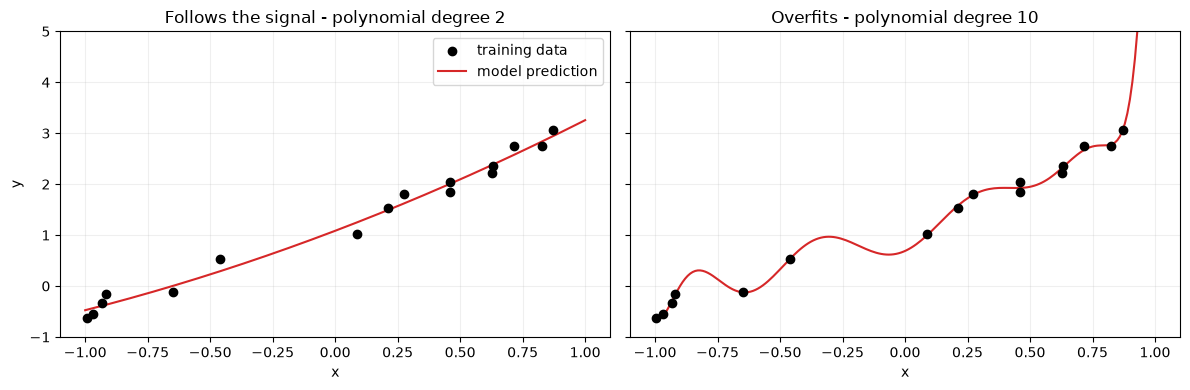

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
models = [("Follows the signal - polynomial degree 2", simple_model),
          ("Overfits - polynomial degree 10", overfit_model)]

for ax, (title, model) in zip(axes, models):
    ax.scatter(x_train, y_train, color="black", label="training data", zorder=3)
    ax.plot(x_test, model(x_test), color="tab:red", label="model prediction")
    ax.set(title=title, xlabel="x", ylim=(-1, 5))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("y")
axes[0].legend()
plt.tight_layout()
plt.show()

## Add L2 regularization

In [88]:
def make_polynomial_features(x, degree):
    # Turn each x into: [x, x^2, x^3, ..., x^degree]
    X = np.zeros((len(x), degree))

    for power in range(1, degree + 1):
        X[:, power - 1] = x ** power

    return X

X_train = make_polynomial_features(x_train, OVERFIT_POLYNOMIAL)
X_test = make_polynomial_features(x_test, OVERFIT_POLYNOMIAL)

In [89]:
def predict_all(X, w, b):
    predictions = np.zeros(len(X))

    for i in range(len(X)):
        predictions[i] = np.dot(X[i], w) + b

    return predictions


def compute_gradient_regularized(X, y, w, b, lambda_):
    m = len(X)
    dj_dw = np.zeros(len(w))
    dj_db = 0.0

    for i in range(m):
        prediction = np.dot(X[i], w) + b
        error = prediction - y[i]

        dj_dw += error * X[i]
        dj_db += error

    dj_dw /= m
    dj_db /= m

    # This is the only new line needed for L2 regularization.
    dj_dw += (lambda_ / m) * w

    return dj_db, dj_dw


def gradient_descent_regularized(
    X, y, learning_rate, num_iters, lambda_
):
    w = np.zeros(X.shape[1])
    b = 0.0

    for _ in range(num_iters):
        dj_db, dj_dw = compute_gradient_regularized(
            X, y, w, b, lambda_
        )

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

    return w, b

In [90]:
# Try 0, 0.01, 0.1, 1, and 10 to see how lambda changes the curve.
LAMBDA = 10

In [91]:
regularized_w, regularized_b = gradient_descent_regularized(
    X_train,
    y_train,
    learning_rate=0.05,
    num_iters=30_000,
    lambda_=LAMBDA,
)

regularized_train_predictions = predict_all(
    X_train, regularized_w, regularized_b
)
regularized_test_predictions = predict_all(
    X_test, regularized_w, regularized_b
)
unregularized_train_predictions = overfit_model(x_train)
unregularized_test_predictions = overfit_model(x_test)

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

print("Degree-10 model without regularization")
print(f"train error: {rmse(y_train, unregularized_train_predictions):.3f}")
print(f"test error:  {rmse(y_test, unregularized_test_predictions):.3f}")

print(f"Degree-10 model with regularization (lambda = {LAMBDA})")
print(f"train error: {rmse(y_train, regularized_train_predictions):.3f}")
print(f"test error:  {rmse(y_test, regularized_test_predictions):.3f}")

Degree-10 model without regularization
train error: 0.052
test error:  1.341
Degree-10 model with regularization (lambda = 10)
train error: 0.544
test error:  0.728


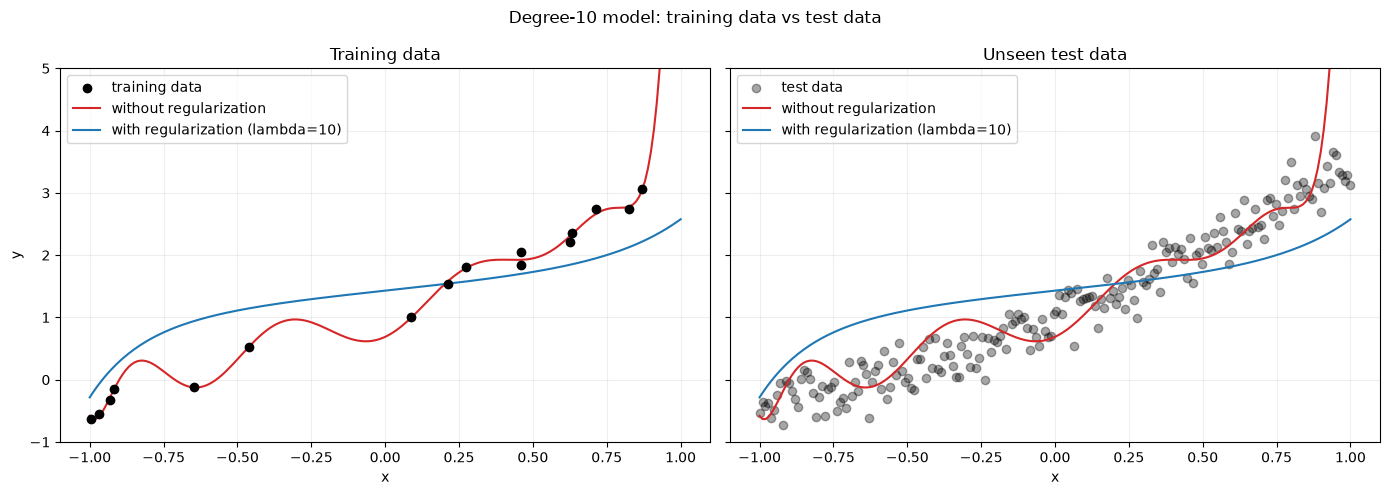

In [92]:
# plot it
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(x_train, y_train, color="black", label="training data", zorder=3)
axes[0].set_title("Training data")

axes[1].scatter(x_test, y_test, color="black", alpha=0.35, label="test data")
axes[1].set_title("Unseen test data")

for ax in axes:
    ax.plot(x_test, unregularized_test_predictions, color="tab:red", label="without regularization")
    ax.plot(x_test, regularized_test_predictions, color="tab:blue", label=f"with regularization (lambda={LAMBDA})")
    ax.set_xlabel("x")
    ax.set_ylim(-1, 5)
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("y")
fig.suptitle("Degree-10 model: training data vs test data")
plt.tight_layout()
plt.show()